## Importation

In [1]:
import os
import glob
import time
import random
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score,
    pairwise_distances,
)
from sklearn.metrics.pairwise import euclidean_distances

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from typing import Tuple, Dict, Any, Optional


/home/yona/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Shared utilities - run before anything else

In [2]:
DATA_ROOT    = '/media/Data/Yona/WSI CCRCC'
CSV_PATH     = f'{DATA_ROOT}/tables/clinical+genomic_split.csv'
FEATURES_DIR = f'{DATA_ROOT}/features_MaxPooling'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class WSIEmbeddingDataset(Dataset):
    def __init__(self, csv_path: str, features_dir: str, split: str = 'train'):
        df     = pd.read_csv(csv_path)[['case_id', 'vital_status_12', 'Split']]
        wanted = split.strip().lower()
        data_list = []
        for _, row in df.iterrows():
            case_id = str(row['case_id']).strip()
            label   = int(row['vital_status_12'])
            if str(row['Split']).strip().lower() != wanted:
                continue
            if case_id.startswith('C'):
                patient_id = case_id
            elif case_id.startswith('T'):
                parts = case_id.split('-')
                if len(parts) < 3:
                    continue
                patient_id = '-'.join(parts[:3])
            else:
                continue
            for fp in glob.glob(os.path.join(features_dir, f'{patient_id}-*.npz')):
                data_list.append({'patient_id': patient_id, 'vital_status': label, 'file_path': fp})
        self.data_list = data_list

    def __len__(self) -> int:
        return len(self.data_list)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        item = self.data_list[idx]
        feat = np.load(item['file_path'])['features']
        if feat.ndim == 1:
            feat = feat[np.newaxis]
        return {
            'patient_id': item['patient_id'],
            'embedding':  torch.tensor(feat[0], dtype=torch.float32),
            'label':      item['vital_status'],
            'file_path':  item['file_path'],
        }


class CombinedWSIDataset(Dataset):
    def __init__(self, ds_train: WSIEmbeddingDataset, ds_val: WSIEmbeddingDataset):
        self.ds_train  = ds_train
        self.ds_val    = ds_val
        self.train_len = len(ds_train)
        self.data_list = ds_train.data_list + ds_val.data_list

    def __len__(self) -> int:
        return self.train_len + len(self.ds_val)

    def __getitem__(self, idx: int):
        return self.ds_train[idx] if idx < self.train_len else self.ds_val[idx - self.train_len]


class TripletDataset(Dataset):
    def __init__(self, triplets_file: str, embedding_dataset: Dataset):
        with open(triplets_file, 'rb') as f:
            self.triplets = pickle.load(f)
        self.embedding_dataset = embedding_dataset

    def __len__(self) -> int:
        return len(self.triplets)

    def __getitem__(self, idx: int):
        a, p, n = self.triplets[idx]
        return (
            self.embedding_dataset[a]['embedding'],
            self.embedding_dataset[p]['embedding'],
            self.embedding_dataset[n]['embedding'],
        )


class DeepEmbeddingNet(nn.Module):
    def __init__(self, input_dim: int = 2048, embedding_dim: int = 256, dropout: float = 0.3):
        super().__init__()
        self.fc1     = nn.Linear(input_dim, 1024)
        self.fc2     = nn.Linear(1024, 512)
        self.fc3     = nn.Linear(512, embedding_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        return F.normalize(self.fc3(x), p=2, dim=1)


class AugmentedPatientDataset(Dataset):
    def __init__(self, embeddings: np.ndarray, labels: np.ndarray,
                 augment: bool = False, noise_std: float = 0.0, augment_factor: int = 1):
        self.augment        = augment
        self.noise_std      = float(noise_std)
        self.augment_factor = int(augment_factor)
        if augment:
            emb_list, lbl_list = [], []
            for emb, lbl in zip(embeddings, labels):
                copies = self.augment_factor if int(lbl) == 0 else 1
                for _ in range(copies):
                    emb_list.append(emb)
                    lbl_list.append(int(lbl))
            self.embeddings = np.array(emb_list, dtype=np.float32)
            self.labels     = np.array(lbl_list, dtype=np.int64)
        else:
            self.embeddings = np.array(embeddings, dtype=np.float32)
            self.labels     = np.array(labels, dtype=np.int64)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int):
        emb = self.embeddings[idx].copy()
        y   = int(self.labels[idx])
        if self.augment and y == 0 and self.noise_std > 0:
            emb += np.random.normal(0, self.noise_std, size=emb.shape).astype(np.float32)
        return torch.tensor(emb, dtype=torch.float32), torch.tensor(y, dtype=torch.long)


class PatientMLP(nn.Module):
    """Shared MLP classifier for Optuna search and final training."""
    def __init__(self, input_dim: int, hidden_dims: list, dropouts: list):
        super().__init__()
        assert len(hidden_dims) == len(dropouts)
        layers, prev = [], input_dim
        for h, d in zip(hidden_dims, dropouts):
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(p=float(d))]
            prev = h
        layers.append(nn.Linear(prev, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def build_patient_dict(dataset) -> Dict:
    patient_dict: Dict = {}
    for idx, item in enumerate(dataset.data_list):
        pid, label = item['patient_id'], int(item['vital_status'])
        if pid in patient_dict:
            patient_dict[pid][1].append(idx)
        else:
            patient_dict[pid] = (label, [idx])
    return patient_dict


def oversample_patient_dict(patient_dict: Dict) -> Dict:
    total0 = sum(len(i) for lbl, i in patient_dict.values() if lbl == 0)
    total1 = sum(len(i) for lbl, i in patient_dict.values() if lbl == 1)
    if total0 == 0 or total0 >= total1:
        return patient_dict
    factor = int(np.ceil(total1 / total0))
    return {pid: (lbl, idxs * factor if lbl == 0 else idxs) for pid, (lbl, idxs) in patient_dict.items()}


def generate_triplets(patient_dict: Dict, seed: int = 42) -> list:
    random.seed(seed)
    pids0 = [p for p, (l, _) in patient_dict.items() if l == 0]
    pids1 = [p for p, (l, _) in patient_dict.items() if l == 1]
    triplets = []
    for pid, (label, indices) in patient_dict.items():
        if len(indices) < 2:
            continue
        neg_pool = pids0 if label == 1 else pids1
        if not neg_pool:
            continue
        for anc in indices:
            pos = random.choice([i for i in indices if i != anc])
            neg = random.choice(patient_dict[random.choice(neg_pool)][1])
            triplets.append((anc, pos, neg))
    return triplets


def aggregate_maxpool(X: np.ndarray, y: np.ndarray, pids: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    agg: Dict = {}
    for emb, lbl, pid in zip(X, y, pids):
        if pid not in agg:
            agg[pid] = {'embs': [], 'label': int(lbl)}
        agg[pid]['embs'].append(emb)
    return (
        np.stack([np.max(np.stack(v['embs']), 0) for v in agg.values()]).astype(np.float32),
        np.array([v['label'] for v in agg.values()], dtype=np.int64),
    )


def load_triplet_model(path: str) -> Tuple[nn.Module, Dict]:
    ckpt  = torch.load(path, map_location='cpu')
    cfg   = ckpt['cfg']
    model = DeepEmbeddingNet(input_dim=2048, embedding_dim=cfg['embedding_dim'], dropout=cfg['dropout']).to(device)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    print('Loaded triplet model cfg:', cfg)
    return model, cfg


@torch.no_grad()
def extract_embeddings(split: str, triplet_model: nn.Module, batch_size: int = 512) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    ds     = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split=split)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)
    Zs, ys, ps = [], [], []
    for batch in loader:
        Zs.append(triplet_model(batch['embedding'].to(device)).cpu().numpy())
        ys.append(np.array(batch['label']))
        ps.append(np.array(batch['patient_id']))
    return np.concatenate(Zs).astype(np.float32), np.concatenate(ys).astype(np.int64), np.concatenate(ps)


Using device: cuda


## 1. Generate train triplets

In [3]:
set_seed(42)

ds_train           = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='train')
patient_dict_train = build_patient_dict(ds_train)
patient_dict_train = oversample_patient_dict(patient_dict_train)
triplets_train     = generate_triplets(patient_dict_train, seed=42)

print(f'Train embeddings: {len(ds_train)}')
print(f'Train patients  : {len({d["patient_id"] for d in ds_train.data_list})}')
print(f'Train triplets  : {len(triplets_train)}')

train_triplets_path = f'{DATA_ROOT}/triplets_from_embeddings.pkl'
with open(train_triplets_path, 'wb') as f:
    pickle.dump(triplets_train, f)
print('Saved to:', train_triplets_path)


Train embeddings: 1662
Train patients  : 479
Train triplets  : 3009
Saved to: /media/Data/Yona/WSI CCRCC/triplets_from_embeddings.pkl


## 2. Generate validation triplets

In [4]:
set_seed(42)

ds_val           = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='validation')
patient_dict_val = build_patient_dict(ds_val)
triplets_val     = generate_triplets(patient_dict_val, seed=42)

n0 = sum(1 for _, (l, _) in patient_dict_val.items() if l == 0)
n1 = sum(1 for _, (l, _) in patient_dict_val.items() if l == 1)
print(f'Validation patients: {len(patient_dict_val)} | label0={n0} | label1={n1}')
print(f'Validation triplets: {len(triplets_val)}')

val_triplets_path = f'{DATA_ROOT}/triplets_validation.pkl'
with open(val_triplets_path, 'wb') as f:
    pickle.dump(triplets_val, f)
print('Saved to:', val_triplets_path)


Validation patients: 18 | label0=9 | label1=9
Validation triplets: 55
Saved to: /media/Data/Yona/WSI CCRCC/triplets_validation.pkl


## 3. Manual grid search - triplet model

In [5]:
train_triplets_path = f'{DATA_ROOT}/triplets_from_embeddings.pkl'
val_triplets_path   = f'{DATA_ROOT}/triplets_validation.pkl'


def _train_triplet_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total = 0.0
    for anc, pos, neg in loader:
        anc, pos, neg = anc.to(device), pos.to(device), neg.to(device)
        loss = loss_fn(model(anc), model(pos), model(neg))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / max(len(loader), 1)


@torch.no_grad()
def _eval_triplet_epoch(model, loader, loss_fn):
    model.eval()
    total = 0.0
    for anc, pos, neg in loader:
        total += loss_fn(model(anc.to(device)), model(pos.to(device)), model(neg.to(device))).item()
    return total / max(len(loader), 1)


def run_trial(cfg, num_epochs=15, patience=4, seed=42):
    set_seed(seed)
    ds_tr = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='train')
    ds_va = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='validation')
    tr_loader = DataLoader(TripletDataset(train_triplets_path, ds_tr), batch_size=cfg['batch_size'], shuffle=True,  drop_last=True)
    va_loader = DataLoader(TripletDataset(val_triplets_path,   ds_va), batch_size=cfg['batch_size'], shuffle=False, drop_last=False)
    model     = DeepEmbeddingNet(input_dim=2048, embedding_dim=cfg['embedding_dim'], dropout=cfg['dropout']).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    loss_fn   = nn.TripletMarginLoss(margin=cfg['margin'], p=2)
    best_val, best_state, bad = float('inf'), None, 0
    for epoch in range(num_epochs):
        tr = _train_triplet_epoch(model, tr_loader, optimizer, loss_fn)
        va = _eval_triplet_epoch(model, va_loader, loss_fn)
        print(f'    epoch {epoch+1}/{num_epochs} | train={tr:.4f} | val={va:.4f}')
        if va < best_val - 1e-4:
            best_val, bad = va, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    return best_val, best_state


search_space = [
    {'lr': 1e-4, 'margin': 0.2, 'embedding_dim': 128, 'dropout': 0.2, 'batch_size': 32, 'weight_decay': 1e-4},
    {'lr': 3e-4, 'margin': 0.3, 'embedding_dim': 128, 'dropout': 0.2, 'batch_size': 32, 'weight_decay': 1e-4},
    {'lr': 1e-3, 'margin': 0.5, 'embedding_dim': 128, 'dropout': 0.2, 'batch_size': 32, 'weight_decay': 1e-4},
    {'lr': 3e-4, 'margin': 0.2, 'embedding_dim': 256, 'dropout': 0.3, 'batch_size': 64, 'weight_decay': 1e-4},
    {'lr': 1e-4, 'margin': 0.5, 'embedding_dim':  64, 'dropout': 0.0, 'batch_size': 64, 'weight_decay': 1e-5},
]

best_cfg, best_val, best_state_gs = None, float('inf'), None
for i, cfg in enumerate(search_space, 1):
    print(f'\n=== Trial {i}/{len(search_space)} === {cfg}')
    val_loss, state = run_trial(cfg, num_epochs=15, patience=4)
    print(f'  -> val_loss: {val_loss:.4f}')
    if val_loss < best_val:
        best_val, best_cfg, best_state_gs = val_loss, cfg, state

print('\nBest cfg:', best_cfg, '| val_loss:', best_val)



=== Trial 1/5 === {'lr': 0.0001, 'margin': 0.2, 'embedding_dim': 128, 'dropout': 0.2, 'batch_size': 32, 'weight_decay': 0.0001}


    epoch 1/15 | train=0.1432 | val=0.0789
    epoch 2/15 | train=0.0999 | val=0.0773
    epoch 3/15 | train=0.0870 | val=0.0826
    epoch 4/15 | train=0.0749 | val=0.0811
    epoch 5/15 | train=0.0631 | val=0.0817
    epoch 6/15 | train=0.0551 | val=0.0755
    epoch 7/15 | train=0.0502 | val=0.0875
    epoch 8/15 | train=0.0410 | val=0.0962
    epoch 9/15 | train=0.0389 | val=0.0770
    epoch 10/15 | train=0.0356 | val=0.0852
  -> val_loss: 0.0755

=== Trial 2/5 === {'lr': 0.0003, 'margin': 0.3, 'embedding_dim': 128, 'dropout': 0.2, 'batch_size': 32, 'weight_decay': 0.0001}
    epoch 1/15 | train=0.2263 | val=0.1674
    epoch 2/15 | train=0.1446 | val=0.1266
    epoch 3/15 | train=0.1275 | val=0.1425
    epoch 4/15 | train=0.1030 | val=0.1414
    epoch 5/15 | train=0.0913 | val=0.1425
    epoch 6/15 | train=0.0842 | val=0.1117
    epoch 7/15 | train=0.0908 | val=0.1070
    epoch 8/15 | train=0.0999 | val=0.1202
    epoch 9/15 | train=0.0963 | val=0.1193
    epoch 10/15 | train=0.0984 

## 4. Final triplet model - train on train + validation

In [6]:
BEST_CFG = {
    'lr':            0.0003,
    'margin':        0.2,
    'embedding_dim': 256,
    'dropout':       0.3,
    'batch_size':    64,
    'weight_decay':  0.0001,
}

set_seed(42)

ds_train    = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='train')
ds_val      = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='validation')
ds_trainval = CombinedWSIDataset(ds_train, ds_val)
print(f'Combined: {len(ds_trainval)} embeddings | {len({d["patient_id"] for d in ds_trainval.data_list})} patients')

patient_dict_tv = build_patient_dict(ds_trainval)
patient_dict_tv = oversample_patient_dict(patient_dict_tv)
triplets_tv     = generate_triplets(patient_dict_tv, seed=42)
print(f'Train+val triplets: {len(triplets_tv)}')

triplets_tv_path = f'{DATA_ROOT}/triplets_trainval.pkl'
with open(triplets_tv_path, 'wb') as f:
    pickle.dump(triplets_tv, f)

triplet_loader = DataLoader(
    TripletDataset(triplets_tv_path, ds_trainval),
    batch_size=BEST_CFG['batch_size'], shuffle=True, drop_last=True, num_workers=0,
)

model     = DeepEmbeddingNet(input_dim=2048, embedding_dim=BEST_CFG['embedding_dim'], dropout=BEST_CFG['dropout']).to(device)
optimizer = optim.Adam(model.parameters(), lr=BEST_CFG['lr'], weight_decay=BEST_CFG['weight_decay'])
loss_fn   = nn.TripletMarginLoss(margin=BEST_CFG['margin'], p=2)

NUM_EPOCHS = 20
model.train()
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    for anc, pos, neg in triplet_loader:
        anc, pos, neg = anc.to(device), pos.to(device), neg.to(device)
        loss = loss_fn(model(anc), model(pos), model(neg))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} | loss={epoch_loss / max(len(triplet_loader), 1):.4f}')

final_model_path = f'{DATA_ROOT}/triplet_model_final_trainval.pth'
torch.save({'cfg': BEST_CFG, 'state_dict': model.state_dict()}, final_model_path)
print('Saved FINAL triplet model to:', final_model_path)


Combined: 1719 embeddings | 497 patients
Train+val triplets: 3073
Epoch 1/20 | loss=0.1841
Epoch 2/20 | loss=0.1144
Epoch 3/20 | loss=0.1028
Epoch 4/20 | loss=0.0949
Epoch 5/20 | loss=0.0869
Epoch 6/20 | loss=0.0799
Epoch 7/20 | loss=0.0734
Epoch 8/20 | loss=0.0669
Epoch 9/20 | loss=0.0645
Epoch 10/20 | loss=0.0615
Epoch 11/20 | loss=0.0613
Epoch 12/20 | loss=0.0608
Epoch 13/20 | loss=0.0670
Epoch 14/20 | loss=0.0665
Epoch 15/20 | loss=0.0667
Epoch 16/20 | loss=0.0569
Epoch 17/20 | loss=0.0490
Epoch 18/20 | loss=0.0526
Epoch 19/20 | loss=0.0616
Epoch 20/20 | loss=0.0566
Saved FINAL triplet model to: /media/Data/Yona/WSI CCRCC/triplet_model_final_trainval.pth


## 5. Embedding visualization (t-SNE + pairwise metrics)

Loaded triplet model cfg: {'lr': 0.0003, 'margin': 0.2, 'embedding_dim': 256, 'dropout': 0.3, 'batch_size': 64, 'weight_decay': 0.0001}


/tmp/ipykernel_2546118/78064053.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ys.append(np.array(batch['label']))
/tmp/ipykernel_2546118/78064053.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ys.append(np.array(batch['label']))



--- ORIGINAL 2048 ---
Train+Val: {'N_used': 1719, 'cosine_intra': 0.14000196754932404, 'cosine_inter': 0.1349244862794876, 'euclidean_intra': 0.5228420495986938, 'euclidean_inter': 0.5135071277618408, 'delta_cosine': -0.005077481269836426, 'delta_euclidean': -0.009334921836853027, 'per_class': {0: {'n': 229, 'cosine_intra': 0.12716209888458252, 'cosine_inter': 0.13492444157600403, 'euclidean_intra': 0.4975893497467041, 'euclidean_inter': 0.5135071873664856, 'delta_cosine': 0.007762342691421509, 'delta_euclidean': 0.015917837619781494}, 1: {'n': 1490, 'cosine_intra': 0.1403040885925293, 'cosine_inter': 0.1349244862794876, 'euclidean_intra': 0.5234361290931702, 'euclidean_inter': 0.5135071873664856, 'delta_cosine': -0.005379602313041687, 'delta_euclidean': -0.00992894172668457}}}
Test:      {'N_used': 415, 'cosine_intra': 0.13609325885772705, 'cosine_inter': 0.13394513726234436, 'euclidean_intra': 0.5145640969276428, 'euclidean_inter': 0.5120699405670166, 'delta_cosine': -0.002148121595

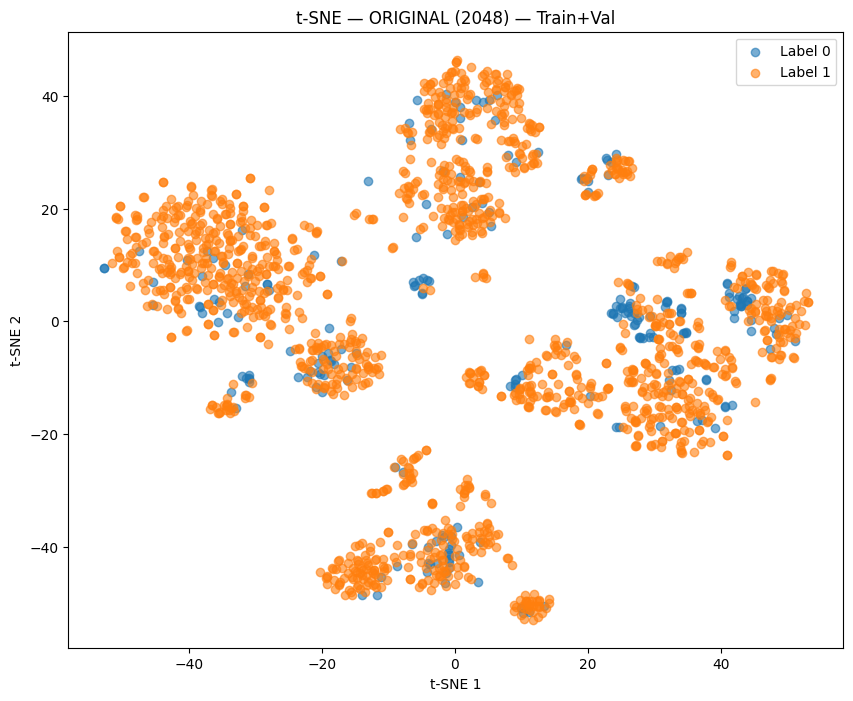

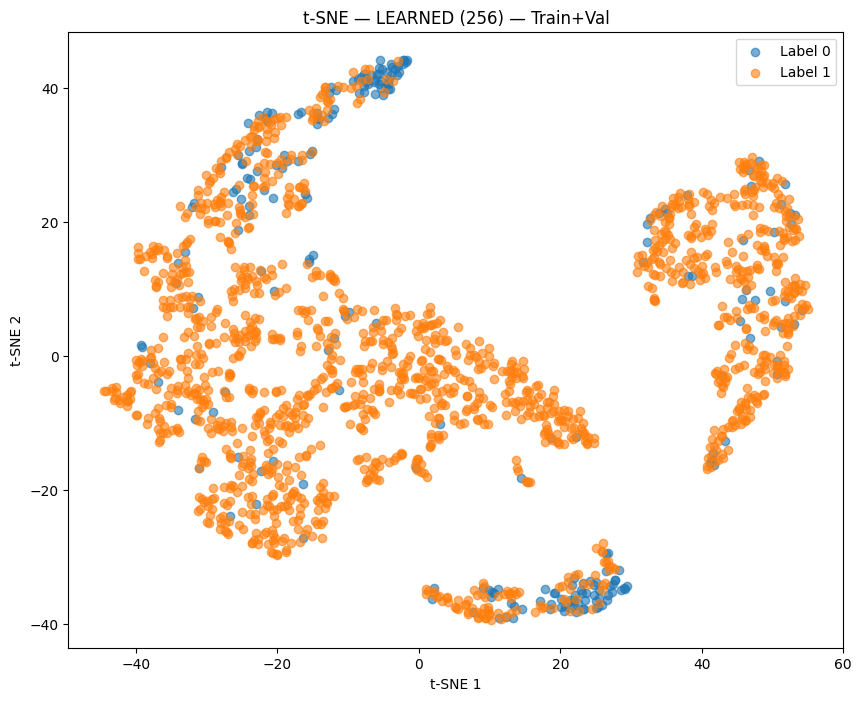

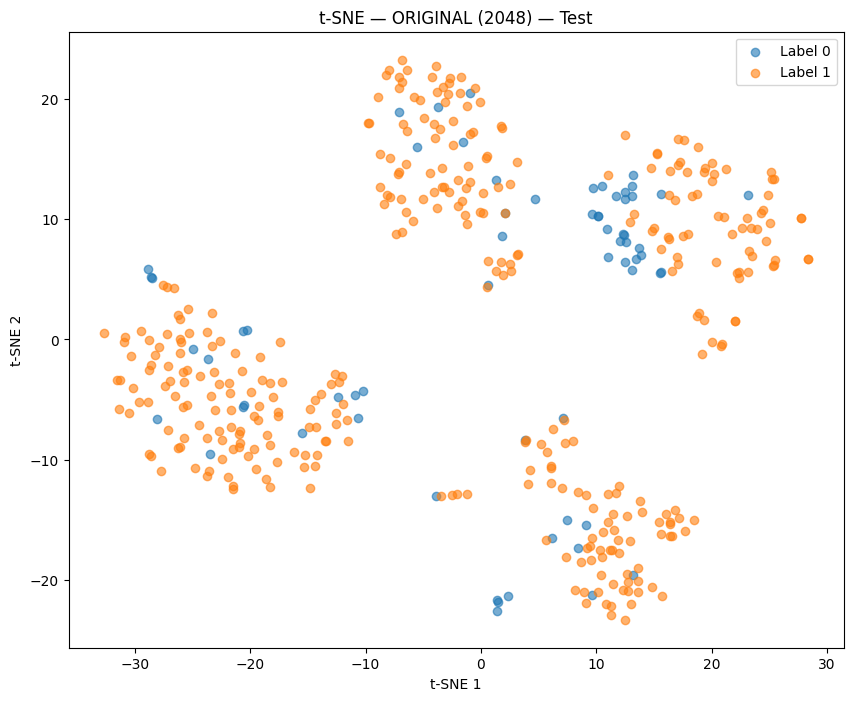

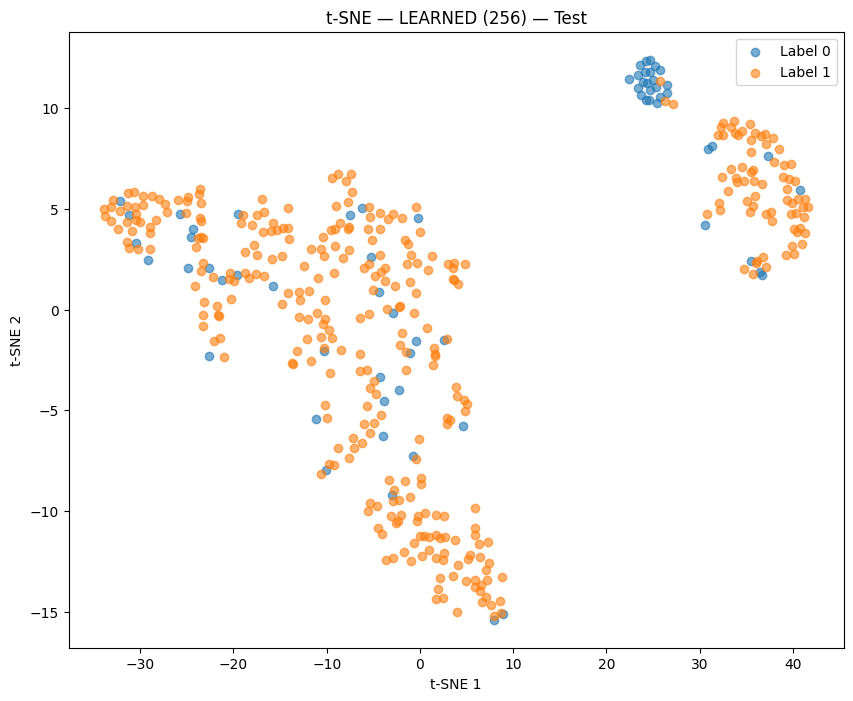

In [7]:
set_seed(42)

ds_train    = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='train')
ds_val      = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='validation')
ds_trainval = CombinedWSIDataset(ds_train, ds_val)
ds_test     = WSIEmbeddingDataset(CSV_PATH, FEATURES_DIR, split='test')

final_model_path    = f'{DATA_ROOT}/triplet_model_final_trainval.pth'
triplet_model, _    = load_triplet_model(final_model_path)


def collect_original_embeddings(dataset, batch_size=512):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)
    Xs, ys, ps = [], [], []
    for batch in loader:
        Xs.append(batch['embedding'].numpy())
        ys.append(np.array(batch['label']))
        ps.append(np.array(batch['patient_id']))
    return np.concatenate(Xs).astype(np.float32), np.concatenate(ys).astype(np.int64), np.concatenate(ps)


@torch.no_grad()
def collect_transformed_embeddings(dataset, model, batch_size=512):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)
    Zs, ys, ps = [], [], []
    for batch in loader:
        Zs.append(model(batch['embedding'].to(device)).cpu().numpy())
        ys.append(np.array(batch['label']))
        ps.append(np.array(batch['patient_id']))
    return np.concatenate(Zs).astype(np.float32), np.concatenate(ys).astype(np.int64), np.concatenate(ps)


def _mean_upper_triangle(mat):
    n = mat.shape[0]
    if n < 2:
        return float('nan'), 0
    vals = mat[np.triu_indices(n, k=1)]
    return (float(np.mean(vals)) if vals.size > 0 else float('nan')), int(vals.size)


def _mean_between_blocks(mat, ia, ib):
    if len(ia) == 0 or len(ib) == 0:
        return float('nan'), 0
    block = mat[np.ix_(ia, ib)]
    return float(np.mean(block)), int(block.size)


def compute_pairwise_metrics(X, y, max_points=3000, seed=42):
    set_seed(seed)
    if X.shape[0] > max_points:
        idx = np.random.choice(X.shape[0], size=max_points, replace=False)
        X, y = X[idx], y[idx]
    N       = X.shape[0]
    cos_mat = pairwise_distances(X, metric='cosine')
    euc_mat = euclidean_distances(X)
    triu    = np.triu_indices(N, k=1)
    same    = y[triu[0]] == y[triu[1]]
    ic, xc  = cos_mat[triu][same],  cos_mat[triu][~same]
    ie, xe  = euc_mat[triu][same],  euc_mat[triu][~same]
    out = {
        'N_used':           N,
        'cosine_intra':     float(np.mean(ic)) if ic.size else float('nan'),
        'cosine_inter':     float(np.mean(xc)) if xc.size else float('nan'),
        'euclidean_intra':  float(np.mean(ie)) if ie.size else float('nan'),
        'euclidean_inter':  float(np.mean(xe)) if xe.size else float('nan'),
        'delta_cosine':     float(np.mean(xc) - np.mean(ic)) if (ic.size and xc.size) else float('nan'),
        'delta_euclidean':  float(np.mean(xe) - np.mean(ie)) if (ie.size and xe.size) else float('nan'),
        'per_class':        {},
    }
    for c in np.unique(y):
        ic_idx, nc_idx = np.where(y == c)[0], np.where(y != c)[0]
        ci,  _ = _mean_upper_triangle(cos_mat[np.ix_(ic_idx, ic_idx)])
        cx,  _ = _mean_between_blocks(cos_mat, ic_idx, nc_idx)
        ei,  _ = _mean_upper_triangle(euc_mat[np.ix_(ic_idx, ic_idx)])
        ex,  _ = _mean_between_blocks(euc_mat, ic_idx, nc_idx)
        out['per_class'][int(c)] = {
            'n': len(ic_idx),
            'cosine_intra': ci,   'cosine_inter': cx,
            'euclidean_intra': ei, 'euclidean_inter': ex,
            'delta_cosine': float(cx - ci) if not (np.isnan(cx) or np.isnan(ci)) else float('nan'),
            'delta_euclidean': float(ex - ei) if not (np.isnan(ex) or np.isnan(ei)) else float('nan'),
        }
    return out


def plot_tsne(X, y, title, max_points=3000, seed=42):
    set_seed(seed)
    if X.shape[0] > max_points:
        idx = np.random.choice(X.shape[0], size=max_points, replace=False)
        X, y = X[idx], y[idx]
    X2 = TSNE(n_components=2, random_state=seed, init='pca', learning_rate='auto').fit_transform(X)
    plt.figure(figsize=(10, 8))
    plt.scatter(X2[y == 0, 0], X2[y == 0, 1], alpha=0.6, label='Label 0')
    plt.scatter(X2[y == 1, 0], X2[y == 1, 1], alpha=0.6, label='Label 1')
    plt.title(title); plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2'); plt.legend(); plt.show()


X_tv, y_tv, _ = collect_original_embeddings(ds_trainval)
X_te, y_te, _ = collect_original_embeddings(ds_test)
norm = lambda X: X / np.clip(np.linalg.norm(X, axis=1, keepdims=True), 1e-12, None)
X_tv_n, X_te_n = norm(X_tv), norm(X_te)

Z_tv, y_tv2, _ = collect_transformed_embeddings(ds_trainval, triplet_model)
Z_te, y_te2, _ = collect_transformed_embeddings(ds_test,     triplet_model)

print('\n--- ORIGINAL 2048 ---')
print('Train+Val:', compute_pairwise_metrics(X_tv_n, y_tv))
print('Test:     ', compute_pairwise_metrics(X_te_n, y_te))

print('\n--- LEARNED 256 ---')
print('Train+Val:', compute_pairwise_metrics(Z_tv, y_tv2))
print('Test:     ', compute_pairwise_metrics(Z_te, y_te2))

plot_tsne(X_tv_n, y_tv,  't-SNE — ORIGINAL (2048) — Train+Val')
plot_tsne(Z_tv,   y_tv2, 't-SNE — LEARNED (256) — Train+Val')
plot_tsne(X_te_n, y_te,  't-SNE — ORIGINAL (2048) — Test')
plot_tsne(Z_te,   y_te2, 't-SNE — LEARNED (256) — Test')


## 6. Optuna hyperparameter search - MLP classifier

In [8]:
final_triplet_path = f'{DATA_ROOT}/triplet_model_final_trainval.pth'
OBJECTIVE_NAME     = 'custom_score'  # or 'macro_f1'

set_seed(42)
triplet_model, triplet_cfg = load_triplet_model(final_triplet_path)

Z_train, y_train, pid_train = extract_embeddings('train',      triplet_model)
Z_val,   y_val,   pid_val   = extract_embeddings('validation', triplet_model)

X_train_agg, y_train_agg = aggregate_maxpool(Z_train, y_train, pid_train)
X_val_agg,   y_val_agg   = aggregate_maxpool(Z_val,   y_val,   pid_val)
print(f'Patients train={X_train_agg.shape[0]} val={X_val_agg.shape[0]}')


def _cls_train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, total = 0.0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * Xb.size(0)
        total += yb.size(0)
    return running_loss / max(total, 1)


@torch.no_grad()
def eval_metrics_with_threshold(model, loader, threshold=0.5):
    model.eval()
    all_labels, all_probs = [], []
    for Xb, yb in loader:
        prob1 = F.softmax(model(Xb.to(device)), dim=1)[:, 1]
        all_probs.extend(prob1.cpu().numpy())
        all_labels.extend(yb.numpy())
    y_true = np.array(all_labels, dtype=int)
    p1     = np.array(all_probs)
    y_pred = (p1 > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall_0    = tn / (tn + fp + 1e-12)
    recall_1    = tp / (tp + fn + 1e-12)
    precision_0 = tn / (tn + fn + 1e-12)
    precision_1 = tp / (tp + fp + 1e-12)
    bacc        = 0.5 * (recall_0 + recall_1)
    f1_0        = 2 * precision_0 * recall_0 / (precision_0 + recall_0 + 1e-12)
    f1_1        = 2 * precision_1 * recall_1 / (precision_1 + recall_1 + 1e-12)
    macro_f1    = 0.5 * (f1_0 + f1_1)
    min_prec    = float(min(precision_0, precision_1))
    auc_val     = roc_auc_score(y_true, p1) if len(np.unique(y_true)) == 2 else np.nan
    return {
        'acc': float(accuracy_score(y_true, y_pred)),
        'bacc': float(bacc), 'auc': float(auc_val),
        'recall_0': float(recall_0),   'recall_1': float(recall_1),
        'precision_0': float(precision_0), 'precision_1': float(precision_1),
        'f1_0': float(f1_0), 'f1_1': float(f1_1),
        'macro_f1': float(macro_f1), 'min_precision': float(min_prec),
        'custom_score': float(0.7 * bacc + 0.3 * min_prec),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'threshold': float(threshold),
    }


def find_best_threshold(model, loader, objective_name='macro_f1'):
    best = None
    for t in np.linspace(0.05, 0.95, 19):
        m = eval_metrics_with_threshold(model, loader, threshold=float(t))
        score = m[objective_name]
        if best is None or score > best[0] or (
            score == best[0] and m['bacc'] > best[1]['bacc']
        ):
            best = (score, m)
    return best[0], best[1]


def run_single_experiment(X_tr, y_tr, X_va, y_va, hidden_dims, dropouts,
                           lr=1e-3, batch_size=16, weight_decay=0.0,
                           noise_std=0.04, augment_factor=6,
                           num_epochs=35, patience=8, seed=42,
                           trial=None, objective_name='macro_f1'):
    set_seed(seed)
    tr_ds  = AugmentedPatientDataset(X_tr, y_tr, augment=True, noise_std=noise_std, augment_factor=augment_factor)
    va_ds  = AugmentedPatientDataset(X_va, y_va, augment=False)
    tr_ld  = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    va_ld  = DataLoader(va_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model  = PatientMLP(X_tr.shape[1], hidden_dims, dropouts).to(device)
    cc     = np.bincount(y_tr.astype(int))
    w      = torch.tensor([1.0 / max(cc[0], 1), 1.0 / max(cc[1], 1)], dtype=torch.float32).to(device)
    crit   = nn.CrossEntropyLoss(weight=w)
    opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    # NOTE: scheduler steps on train_loss — consider va_loss for correct ReduceLROnPlateau use
    sched  = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
    best_score, best_epoch, best_state, best_m, no_imp = -1e9, -1, None, None, 0
    for epoch in range(num_epochs):
        tr_loss = _cls_train_epoch(model, tr_ld, opt, crit)
        sched.step(tr_loss)
        score, vm = find_best_threshold(model, va_ld, objective_name=objective_name)
        if trial is not None:
            trial.report(score, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
        if score > best_score:
            best_score, best_epoch, best_m, no_imp = score, epoch + 1, vm, 0
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        else:
            no_imp += 1
            if no_imp >= patience:
                break
    model.load_state_dict(best_state)
    final_score, final_m = find_best_threshold(model, va_ld, objective_name=objective_name)
    return final_score, final_m, best_epoch


def make_objective(X_tr, y_tr, X_va, y_va, base_seed=42, objective_name='macro_f1'):
    def objective(trial: optuna.Trial) -> float:
        n_layers    = trial.suggest_int('n_layers', 2, 4)
        hidden_dims = [trial.suggest_categorical(f'h{i+1}', [32, 64, 128, 256, 512]) for i in range(n_layers)]
        dropouts    = [trial.suggest_float(f'dropout{i+1}', 0.0, 0.6) for i in range(n_layers)]
        lr          = trial.suggest_float('lr', 1e-5, 5e-3, log=True)
        wd          = trial.suggest_float('weight_decay', 1e-8, 1e-3, log=True)
        bs          = trial.suggest_categorical('batch_size', [8, 16, 32, 64])
        noise_std   = trial.suggest_categorical('noise_std', [0.0, 0.01, 0.02, 0.04, 0.06])
        aug_factor  = trial.suggest_int('augment_factor', 1, 10)
        num_epochs  = trial.suggest_int('num_epochs', 10, 60)
        patience    = trial.suggest_int('patience', 5, 15)
        score, vm, best_ep = run_single_experiment(
            X_tr, y_tr, X_va, y_va,
            hidden_dims=hidden_dims, dropouts=dropouts,
            lr=lr, batch_size=bs, weight_decay=wd,
            noise_std=noise_std, augment_factor=aug_factor,
            num_epochs=num_epochs, patience=patience,
            seed=base_seed, trial=trial, objective_name=objective_name,
        )
        trial.set_user_attr('best_epoch', int(best_ep))
        trial.set_user_attr('best_threshold', float(vm['threshold']))
        for k in ['acc','bacc','auc','recall_0','recall_1','precision_0','precision_1','macro_f1','min_precision','custom_score']:
            trial.set_user_attr(f'val_{k}', float(vm[k]))
        trial.set_user_attr('confusion', {'tn':int(vm['tn']),'fp':int(vm['fp']),'fn':int(vm['fn']),'tp':int(vm['tp'])})
        trial.set_user_attr('hidden_dims', hidden_dims)
        trial.set_user_attr('dropouts', dropouts)
        return float(score)
    return objective


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42, multivariate=True),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=5),
    study_name=f'mlp_optuna_{OBJECTIVE_NAME}',
)
t0 = time.time()
study.optimize(make_objective(X_train_agg, y_train_agg, X_val_agg, y_val_agg,
                               base_seed=42, objective_name=OBJECTIVE_NAME),
               n_trials=80, show_progress_bar=True)
print(f'\nOptuna done in {time.time()-t0:.1f}s')
print(f'Best {OBJECTIVE_NAME}:', study.best_value)
print('Best params:', study.best_params)
print('Best user_attrs:', study.best_trial.user_attrs)



Loaded triplet model cfg: {'lr': 0.0003, 'margin': 0.2, 'embedding_dim': 256, 'dropout': 0.3, 'batch_size': 64, 'weight_decay': 0.0001}


/tmp/ipykernel_2546118/809915720.py:216: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ys.append(np.array(batch['label']))
/tmp/ipykernel_2546118/809915720.py:216: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ys.append(np.array(batch['label']))
/home/yona/miniconda3/lib/python3.12/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2026-06-08 18:12:0

Patients train=479 val=18


Best trial: 0. Best value: 0.35:   1%|▏         | 1/80 [00:01<01:35,  1.21s/it]

[I 2026-06-08 18:12:02,554] Trial 0 finished with value: 0.34999999999996106 and parameters: {'n_layers': 3, 'h1': 32, 'h2': 64, 'h3': 32, 'dropout1': 0.18254534577572262, 'dropout2': 0.3148538589793427, 'dropout3': 0.25916701118526947, 'lr': 6.109683510122488e-05, 'weight_decay': 1.1462107403425014e-05, 'batch_size': 64, 'noise_std': 0.0, 'augment_factor': 7, 'num_epochs': 18, 'patience': 5}. Best is trial 0 with value: 0.34999999999996106.


...

[I 2026-06-08 18:17:55,965] Trial 77 finished with value: 0.7521367521366755 and parameters: {'n_layers': 2, 'h1': 256, 'h2': 512, 'dropout1': 0.43122687163313445, 'dropout2': 0.4391126092141412, 'lr': 6.764678198568672e-05, 'weight_decay': 7.902239384017685e-07, 'batch_size': 64, 'noise_std': 0.01, 'augment_factor': 7, 'num_epochs': 22, 'patience': 9}. Best is trial 50 with value: 0.7626262626261822.
[W 2026-06-08 18:17:56,008] The parameter 'h3' in trial#78 is sampled independently instead of being sampled by multivariate TPE sampler. (optimization performance may be degraded). You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler`, if this independent sampling is intended behavior.
[W 2026-06-08 18:17:56,012] The parameter 'dropout3' in trial#78 is sampled independently instead of being sampled by multivariate TPE sampler. (optimization performance may be degraded). You can suppress this warning by setting `warn_independent

Best trial: 50. Best value: 0.762626:  99%|█████████▉| 79/80 [05:56<00:02,  2.32s/it]

[I 2026-06-08 18:17:58,095] Trial 78 finished with value: 0.6077777777777122 and parameters: {'n_layers': 3, 'h1': 256, 'h2': 512, 'h3': 512, 'dropout1': 0.4382740344066322, 'dropout2': 0.30523449537440595, 'dropout3': 0.22860634858869072, 'lr': 0.0004005630960473894, 'weight_decay': 2.9295827950036337e-05, 'batch_size': 64, 'noise_std': 0.01, 'augment_factor': 6, 'num_epochs': 17, 'patience': 10}. Best is trial 50 with value: 0.7626262626261822.


Best trial: 50. Best value: 0.762626: 100%|██████████| 80/80 [05:57<00:00,  4.47s/it]

[I 2026-06-08 18:17:59,024] Trial 79 pruned. 

Optuna done in 357.7s
Best custom_score: 0.7626262626261822
Best params: {'n_layers': 3, 'h1': 512, 'h2': 64, 'h3': 512, 'dropout1': 0.5630113519488746, 'dropout2': 0.34701149217620697, 'dropout3': 0.20170906968702756, 'lr': 1.6913245547160562e-05, 'weight_decay': 3.7190395920084656e-08, 'batch_size': 8, 'noise_std': 0.02, 'augment_factor': 8, 'num_epochs': 12, 'patience': 11}
Best user_attrs: {'best_epoch': 11, 'best_threshold': 0.2, 'val_acc': 0.7777777777777778, 'val_bacc': 0.7777777777776913, 'val_auc': 0.7283950617283951, 'val_recall_0': 0.8888888888887901, 'val_recall_1': 0.6666666666665926, 'val_precision_0': 0.7272727272726611, 'val_precision_1': 0.8571428571427346, 'val_macro_f1': 0.7749999999994195, 'val_min_precision': 0.7272727272726611, 'val_custom_score': 0.7626262626261822, 'confusion': {'tn': 8, 'fp': 1, 'fn': 3, 'tp': 6}, 'hidden_dims': [512, 64, 512], 'dropouts': [0.5630113519488746, 0.34701149217620697, 0.201709069687027

## 7. Final MLP - train on train only, evaluate on test

Loaded triplet model cfg: {'lr': 0.0003, 'margin': 0.2, 'embedding_dim': 256, 'dropout': 0.3, 'batch_size': 64, 'weight_decay': 0.0001}


/tmp/ipykernel_2546118/809915720.py:216: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ys.append(np.array(batch['label']))
/tmp/ipykernel_2546118/809915720.py:216: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  ys.append(np.array(batch['label']))
/tmp/ipykernel_2546118/809915720.py:216: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the

Patients — train:479 val:18 test:120
Epoch 1/30 | Train Loss=0.6845 Acc=0.5231 || Val Loss=0.6808 Acc=0.5000
Epoch 2/30 | Train Loss=0.6705 Acc=0.5393 || Val Loss=0.6670 Acc=0.5000
Epoch 3/30 | Train Loss=0.6528 Acc=0.5371 || Val Loss=0.6520 Acc=0.5000
Epoch 4/30 | Train Loss=0.6343 Acc=0.5382 || Val Loss=0.6351 Acc=0.5000
Epoch 5/30 | Train Loss=0.6119 Acc=0.5382 || Val Loss=0.6130 Acc=0.5000
Epoch 6/30 | Train Loss=0.5821 Acc=0.5382 || Val Loss=0.5865 Acc=0.5000
Epoch 7/30 | Train Loss=0.5414 Acc=0.5382 || Val Loss=0.5517 Acc=0.5000
Epoch 8/30 | Train Loss=0.4966 Acc=0.5382 || Val Loss=0.5112 Acc=0.5000
Epoch 9/30 | Train Loss=0.4492 Acc=0.5382 || Val Loss=0.4695 Acc=0.5000
Epoch 10/30 | Train Loss=0.4079 Acc=0.5382 || Val Loss=0.4365 Acc=0.5000
Epoch 11/30 | Train Loss=0.3762 Acc=0.5382 || Val Loss=0.4103 Acc=0.5000
Epoch 12/30 | Train Loss=0.3639 Acc=0.5382 || Val Loss=0.3926 Acc=0.5000
Epoch 13/30 | Train Loss=0.3408 Acc=0.5382 || Val Loss=0.3831 Acc=0.5000
Epoch 14/30 | Train Los

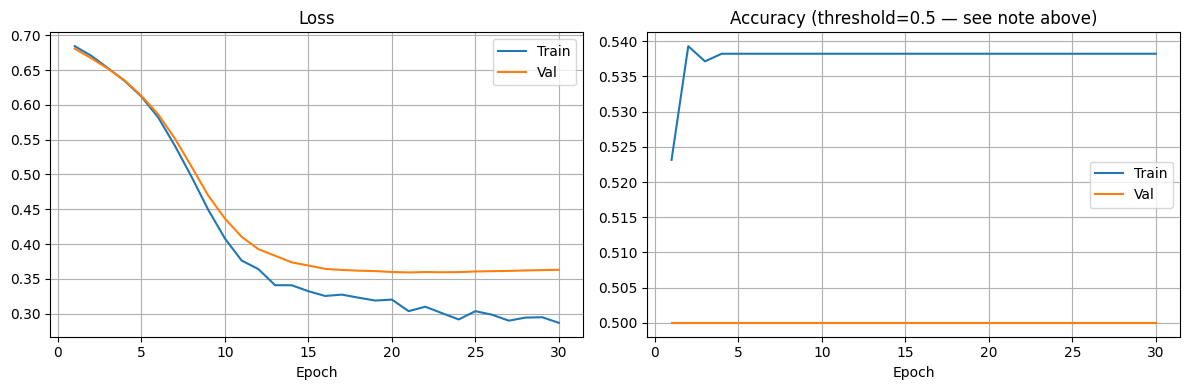


TEST RESULTS  (threshold=0.16)
ACC    : 0.3917
BACC   : 0.5168
AUC    : 0.6400
Recall  class0=0.6875  class1=0.3462
Precision class0=0.1392  class1=0.8780
Macro-F1: 0.3641
Confusion (tn,fp,fn,tp): 11,5,68,36

                  precision    recall  f1-score   support

Non-survivor (0)       0.14      0.69      0.23        16
    Survivor (1)       0.88      0.35      0.50       104

        accuracy                           0.39       120
       macro avg       0.51      0.52      0.36       120
    weighted avg       0.78      0.39      0.46       120



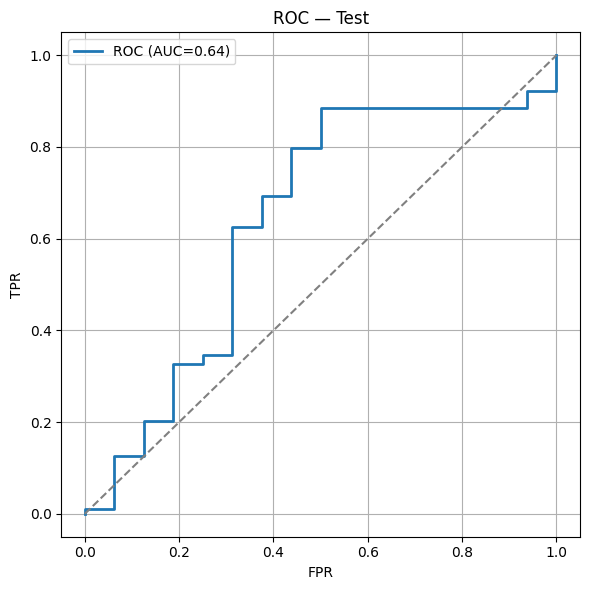

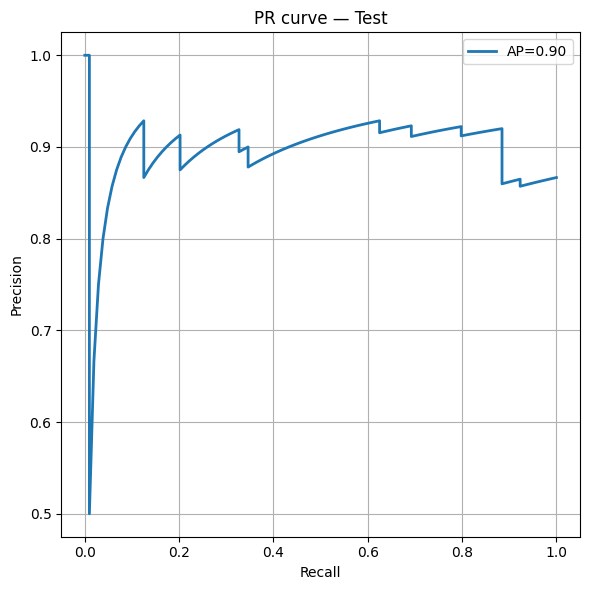

In [9]:
CFG = {
    'final_triplet_path': f'{DATA_ROOT}/triplet_model_final_trainval.pth',
    'hidden_dims':  [256, 128, 256],
    'dropouts':     [0.36904197341483075, 0.5386621403300805, 0.391637299515159],
    'lr':           1.8550553065021572e-05,
    'weight_decay': 7.846881096501333e-05,
    'batch_size':   16,
    'noise_std':    0.0,
    'augment_factor': 10,
    'num_epochs':   30,
    'threshold':    0.16,
    'val_split':    'validation',
    'seed':         42,
}

set_seed(CFG['seed'])
triplet_model, _ = load_triplet_model(CFG['final_triplet_path'])

Z_train, y_train, pid_train = extract_embeddings('train',         triplet_model)
Z_val,   y_val,   pid_val   = extract_embeddings(CFG['val_split'], triplet_model)
Z_test,  y_test,  pid_test  = extract_embeddings('test',          triplet_model)

X_train_agg, y_train_agg = aggregate_maxpool(Z_train, y_train, pid_train)
X_val_agg,   y_val_agg   = aggregate_maxpool(Z_val,   y_val,   pid_val)
X_test_agg,  y_test_agg  = aggregate_maxpool(Z_test,  y_test,  pid_test)
print(f'Patients — train:{X_train_agg.shape[0]} val:{X_val_agg.shape[0]} test:{X_test_agg.shape[0]}')

tr_ds  = AugmentedPatientDataset(X_train_agg, y_train_agg, augment=True,  noise_std=CFG['noise_std'], augment_factor=CFG['augment_factor'])
va_ds  = AugmentedPatientDataset(X_val_agg,   y_val_agg,   augment=False)
te_ds  = AugmentedPatientDataset(X_test_agg,  y_test_agg,  augment=False)
tr_ld  = DataLoader(tr_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=0)
va_ld  = DataLoader(va_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=0)
te_ld  = DataLoader(te_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=0)

model  = PatientMLP(X_train_agg.shape[1], CFG['hidden_dims'], CFG['dropouts']).to(device)
cc     = np.bincount(y_train_agg.astype(int))
w      = torch.tensor([1.0/max(cc[0],1), 1.0/max(cc[1],1)], dtype=torch.float32).to(device)
crit   = nn.CrossEntropyLoss(weight=w)
opt    = optim.Adam(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
sched  = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)

train_losses, train_accs, val_losses, val_accs = [], [], [], []

for epoch in range(CFG['num_epochs']):
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    for Xb, yb in tr_ld:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        logits = model(Xb)
        loss   = crit(logits, yb)
        loss.backward()
        opt.step()
        run_loss += loss.item() * Xb.size(0)
        correct  += (logits.argmax(1) == yb).sum().item()
        total    += yb.size(0)
    tr_loss = run_loss / max(total, 1)
    tr_acc  = correct  / max(total, 1)

    model.eval()
    with torch.no_grad():
        run_loss, correct, total = 0.0, 0, 0
        for Xb, yb in va_ld:
            Xb, yb = Xb.to(device), yb.to(device)
            logits  = model(Xb)
            run_loss += crit(logits, yb).item() * Xb.size(0)
            correct  += (logits.argmax(1) == yb).sum().item()
            total    += yb.size(0)
    va_loss = run_loss / max(total, 1)
    va_acc  = correct  / max(total, 1)

    sched.step(va_loss)
    train_losses.append(tr_loss); train_accs.append(tr_acc)
    val_losses.append(va_loss);   val_accs.append(va_acc)
    print(f'Epoch {epoch+1}/{CFG["num_epochs"]} | '
          f'Train Loss={tr_loss:.4f} Acc={tr_acc:.4f} || '
          f'Val Loss={va_loss:.4f} Acc={va_acc:.4f}')

epochs = range(1, CFG['num_epochs'] + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, train_losses, label='Train'); axes[0].plot(epochs, val_losses, label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True); axes[0].legend()
axes[1].plot(epochs, train_accs,  label='Train'); axes[1].plot(epochs, val_accs,  label='Val')
axes[1].set_title('Accuracy (threshold=0.5 — see note above)')
axes[1].set_xlabel('Epoch'); axes[1].grid(True); axes[1].legend()
plt.tight_layout(); plt.show()


# ── Test evaluation ──
model.eval()
ys, p1s = [], []
with torch.no_grad():
    for Xb, yb in te_ld:
        p1s.append(F.softmax(model(Xb.to(device)), dim=1)[:, 1].cpu().numpy())
        ys.append(yb.numpy())
y_true = np.concatenate(ys).astype(int)
p1     = np.concatenate(p1s).astype(float)
thr    = CFG['threshold']
y_pred = (p1 > thr).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
recall_0    = tn / (tn + fp + 1e-12)
recall_1    = tp / (tp + fn + 1e-12)
precision_0 = tn / (tn + fn + 1e-12)
precision_1 = tp / (tp + fp + 1e-12)
bacc        = 0.5 * (recall_0 + recall_1)
f1_0        = 2*precision_0*recall_0/(precision_0+recall_0+1e-12)
f1_1        = 2*precision_1*recall_1/(precision_1+recall_1+1e-12)
auc_score   = roc_auc_score(y_true, p1)

print(f'\nTEST RESULTS  (threshold={thr})')
print(f'ACC    : {accuracy_score(y_true, y_pred):.4f}')
print(f'BACC   : {bacc:.4f}')
print(f'AUC    : {auc_score:.4f}')
print(f'Recall  class0={recall_0:.4f}  class1={recall_1:.4f}')
print(f'Precision class0={precision_0:.4f}  class1={precision_1:.4f}')
print(f'Macro-F1: {0.5*(f1_0+f1_1):.4f}')
print(f'Confusion (tn,fp,fn,tp): {tn},{fp},{fn},{tp}')
print()
print(classification_report(y_true, y_pred, target_names=['Non-survivor (0)', 'Survivor (1)']))

fpr, tpr, _ = roc_curve(y_true, p1)
roc_auc     = auc(fpr, tpr)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC — Test'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(y_true, p1)
ap = average_precision_score(y_true, p1)
plt.figure(figsize=(6, 6))
plt.plot(recall_curve, precision_curve, lw=2, label=f'AP={ap:.2f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR curve — Test'); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()
